In [26]:
# Importing the packages
import h5py
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import axes3d

In [27]:
# Cosmological constants
H_0 = 70/1000 # km s^-1 kpc^-1
h_denominator = 100/1000 # km s^-1 kpc^-1
h_exp = H_0/h_denominator
h_no_exp = 1
omega_m = 0.3
omega_lambda = 0.7

# Defining the values and data we are going to use for the results of the 
# radial density profile and energy evolution of a collapsing sphere
# REMEMBER TO DIVIDE BY THE CONSTANT h FOR EXPANDING UNIVERSE
n_particles = 3000
mass_units = 1e10 # Msun
mass = 1e12/mass_units # in code units
radius = 150 # kpc
sphere_volume = ((4*np.pi)/3)*(radius)**3
box_volume = (2*radius)**3
#G = 6.674*10**(-11) # m^3 kg^-1 s^2
G_gadget = 43007.1 # kpc (km/s)^2 (1e10 Msun)^-1 
G_physical = G_gadget/1e10 # kpc (km/s)^2 (Msun)^-1

# Defining the functions to calculate the free-fall time in code units
# Also defining a function to  calculate the Hubble parameter for the simulation
density = mass/sphere_volume

def free_fall_time(rho):
    denominator = 32*G_gadget*rho
    return np.sqrt((3*np.pi)/denominator)

sim_time = 3*free_fall_time(density)
print("")
print(f"The time that the simulation must last is t = {sim_time:.3f} [kpc/(km/s)] \n")

def Hubble_constant(z):
    inside_sqrt = omega_m*((1+z)**3) + omega_lambda
    return H_0*np.sqrt(inside_sqrt) # use a redshift value of z>3

# Calculating and generating the random positions of the particles in the sphere 
# In an inscribed sphere in a box, the radius = side/2, then ratio is pi/6
volumes_ratio = box_volume/sphere_volume

# Generating the random positions of the particles in the x axis and the y axis
# in a cartesian grid
# To have 300o particles in a sphere we must scale by the ratio of volumes factor
# which yields a number of approximately 6000 enclosed particles in the cube
n_particles_box = int(n_particles*volumes_ratio)
x_pos = np.random.uniform(-radius, radius, n_particles_box)
y_pos = np.random.uniform(-radius, radius, n_particles_box)
z_pos = np.random.uniform(-radius, radius, n_particles_box)
pos_0 = np.stack([x_pos, y_pos, z_pos], axis=1) # stacked about axis=1
    
# Calculating the radial distances of the particles from the center
radial_0 = np.linalg.norm(pos_0, axis=1)

# Masking to deprecate the particles that are not located inside the sphere
mask = radial_0 <= radius
pos = pos_0[mask]
number_particles = len(pos)
mass_particle = mass/number_particles
print(f"Actual number of particles inside the sphere: {number_particles} \n")

# Calculating the mean interparticle distance and its related grav_softening
mean_interp_distance = (sphere_volume/number_particles)**(1/3)
grav_soft = mean_interp_distance/30
print(f"The gravitational softening is given by Grav_soft = {grav_soft:.3f} [kpc] \n")

# Redefining the radial positions for the sphere-enclosed particles and
# defining their velocities array
radial = np.linalg.norm(pos, axis=1)
vel_no_exp = np.full_like(pos, 0)
Hubble = Hubble_constant(z=4)
vel_exp = Hubble*pos # km s^-1 (3D-vector) for expanding universe

# Creating particles ids to create the hdf5 file for the simulation
particle_ids = random.sample(range(0, 10000), number_particles)


The time that the simulation must last is t = 2.952 [kpc/(km/s)] 

Actual number of particles inside the sphere: 2988 

The gravitational softening is given by Grav_soft = 0.560 [kpc] 



In [28]:
"Creation of the HDF5 file for the exercise 4 in the first module"

"Non-expanding-Universe"

print("")
print("Non-Expanding Universe File")

# Creating the file
with h5py.File("hdf5_ex4_no_exp.hdf5", "w") as f:
    grp_init = f.create_group("Header") # header
    grp_init.attrs["NumPart_ThisFile"] = np.array([0, number_particles])
    grp_init.attrs["NumPart_Total"] = np.array([0, number_particles])
    grp_init.attrs["MassTable"] = np.array([0, mass_particle])
    grp_init.attrs["NumFilesPerSnapshot"] = 1
    grp_init.attrs["Time"] = 0.0
    grp_init.attrs["Redshift"] = 0.0
    grp_init.attrs["BoxSize"] = 0.0
    grp_part = f.create_group("PartType1") # parttype1
    subgrp_coord = grp_part.create_dataset("Coordinates", data=pos.astype(np.float32))
    subgrp_vel = grp_part.create_dataset("Velocities", data=vel_no_exp.astype(np.float32))
    subgrp_ids = grp_part.create_dataset("ParticleIDs", data=np.array(particle_ids, dtype=(np.uint32)))

with h5py.File("hdf5_ex4_no_exp.hdf5", "r") as f:
    print("--Keys--")
    print(list(f.keys()))
    print("")
    print("--PartType1--")
    pos = np.asarray(f["PartType1/Coordinates"])
    vel = np.asarray(f["PartType1/Velocities"])
    ids = np.asarray(f["PartType1/ParticleIDs"])
    print(list(f["PartType1"].keys()))
    print("")
    print("--Header Attributes--")
    header = f["Header"].attrs
    num_p = header["NumPart_ThisFile"]
    mass_table = header["MassTable"]
    print(list(f["Header"].attrs))
    print("")
    #print(mass_table)


Non-Expanding Universe File
--Keys--
['Header', 'PartType1']

--PartType1--
['Coordinates', 'ParticleIDs', 'Velocities']

--Header Attributes--
['BoxSize', 'MassTable', 'NumFilesPerSnapshot', 'NumPart_ThisFile', 'NumPart_Total', 'Redshift', 'Time']



In [29]:
"Expanding Universe"

print("")
print("Expanding Universe File")

# Creating the file
with h5py.File("hdf5_ex4_exp.hdf5", "w") as f:
    grp_init = f.create_group("Header") # header
    grp_init.attrs["NumPart_ThisFile"] = np.array([0, number_particles])
    grp_init.attrs["NumPart_Total"] = np.array([0, number_particles])
    grp_init.attrs["MassTable"] = np.array([0, mass_particle])
    grp_init.attrs["NumFilesPerSnapshot"] = 1
    grp_init.attrs["Time"] = 0.0
    grp_init.attrs["Redshift"] = 4.0
    grp_init.attrs["BoxSize"] = 0.0
    grp_part = f.create_group("PartType1") # parttype1
    subgrp_coord = grp_part.create_dataset("Coordinates", data=pos.astype(np.float32))
    subgrp_vel = grp_part.create_dataset("Velocities", data=vel_exp.astype(np.float32))
    subgrp_ids = grp_part.create_dataset("ParticleIDs", data=np.array(particle_ids, dtype=(np.uint32)))

with h5py.File("hdf5_ex4_exp.hdf5", "r") as f:
    print("--Keys--")
    print(list(f.keys()))
    print("")
    print("--PartType1--")
    pos_exp_file = np.asarray(f["PartType1/Coordinates"])
    vel_exp_file = np.asarray(f["PartType1/Velocities"])
    ids_exp_file = np.asarray(f["PartType1/ParticleIDs"])
    print(list(f["PartType1"].keys()))
    print("")
    print("--Header Attributes--")
    header_exp = f["Header"].attrs
    num_p_exp = header_exp["NumPart_ThisFile"]
    mass_table_exp = header_exp["MassTable"]
    print(list(f["Header"].attrs))
    print("")
    #print(mass_table)


Expanding Universe File
--Keys--
['Header', 'PartType1']

--PartType1--
['Coordinates', 'ParticleIDs', 'Velocities']

--Header Attributes--
['BoxSize', 'MassTable', 'NumFilesPerSnapshot', 'NumPart_ThisFile', 'NumPart_Total', 'Redshift', 'Time']



In [30]:
"Analysis and Plotting for the Non-Expanding Universe"
    
"Calculation and plotting of the radial density profile"

# Importing the hdf5 snapshot file from the Gadget compilation and printing
# relevant information
h5py_file = "C:\\Users\\aleja\\astrofisica_teorica\\sim_num\\claudio_nbody\\output_ex4\\snapshot_006.hdf5"

with h5py.File(h5py_file, "r") as f:
    pos1 = np.asarray(f["/PartType1/Coordinates"]) # kpc/h
    info = np.asarray(f["/PartType1/Velocities"]) # kpc/h
    print("---File Information---")
    print(list(f.keys()))
    print(list(f["PartType1"].keys()))
    header = f["Header"].attrs
    #mass = header["MassTable"] # 1e10 Msun/h
    #stellar_mass = mass[1] # 1e10 Msun/h
    print("")
    print("---Attributes in Header---")
    for key in header.keys():
        value = header[key]
        print(f"{key}: {value}")

# Generating firstly the density profile by using np.histogram
radial_output = np.linalg.norm(pos1, axis=1)
nbins = 30  
weight_array = np.full_like(radial_output, mass_particle*mass_units)
r_min, r_max = radial_output.min(), radial_output.max()
bin_edges = np.logspace(np.log10(r_min), np.log10(r_max), nbins + 1)
hist, edges = np.histogram(radial_output, bins=bin_edges, range=(r_min, r_max), weights=weight_array)

# Calculating the volume density (remember bins are spherical shells)
# Lets calculate the volume 
radius_outer = edges[1:]
radius_inner = edges[:-1]
shell_volume = (4*np.pi/3)*(radius_outer**3 - radius_inner**3)
vol_density = hist/shell_volume
# Geometrical mean for the radial value because of logarithmic binning
bin_centers = np.sqrt(radius_inner*radius_outer)

# Masking the values for the fitting procedure
mask = vol_density > 0
bin_centers = bin_centers[mask]
vol_density = vol_density[mask]
#vol_density_physical = vol_density*mass_units

# Fit the curve obtained to see the log-log slope 
log_r = np.log10(bin_centers)
log_rho = np.log10(vol_density)

# Printing the value of the slope with polyfit
#mask = vol_density > 0
slope, intercept = np.polyfit(np.log10(bin_centers), np.log10(vol_density), 1)
print(f"Power law index slope: {-slope:.2f}")

# Add here the NFW fitting (with the code of ex5)

# Defining the critical density value
rho_crit = (3*(H_0)**2)/(8*np.pi*G_physical) # Msun kpc^-3
print(f"\nCritical density value: {rho_crit:.3f} [Msun kpc^-3]")

# Fitting to the log NFW profile for a better convergence of the parameters
def log_NFW_profile(radius, log_delta_c, log_scale_radius):
    delta_c = 10**(log_delta_c)
    scale_radius = 10**(log_scale_radius)
    denominator = (radius/scale_radius)*(1 + radius/scale_radius)**2
    return np.log10((rho_crit*delta_c)/(denominator))

# Obtaining the parameter values of delta_c and the scale radius
p0 = [3, 1]
popt, pcov = curve_fit(log_NFW_profile, bin_centers, log_rho, p0=p0, maxfev=10000)
delta_c = 10**(popt[0])
scale_radius = 10**(popt[1]) # kpc
rho_nfw_fit = 10**log_NFW_profile(bin_centers, popt[0], popt[1])
print(f"\nValues of the parameters for non-expanding universe:\ndelta_c = {delta_c:.3f} + {pcov[0][0]:.3f}, r_s = {scale_radius:.3f} + {pcov[1][1]} [kpc]")

---File Information---
['Config', 'Header', 'Parameters', 'PartType1']
['Coordinates', 'ParticleIDs', 'Velocities']

---Attributes in Header---
BoxSize: 0.0
Git_commit: b'6e4f1128ac696260d3f2aff68cb6fa7b335e4c1c'
Git_date: b'Tue May 20 19:00:00 2025 +0200'
MassTable: [0.        0.0333667]
NumFilesPerSnapshot: 1
NumPart_ThisFile: [   0 2997]
NumPart_Total: [   0 2997]
Redshift: 0.0
Time: 3.0
Power law index slope: 2.52

Critical density value: 136.000 [Msun kpc^-3]

Values of the parameters for non-expanding universe:
delta_c = 6372.365 + 0.355, r_s = 24.487 + 0.056130572009700334 [kpc]


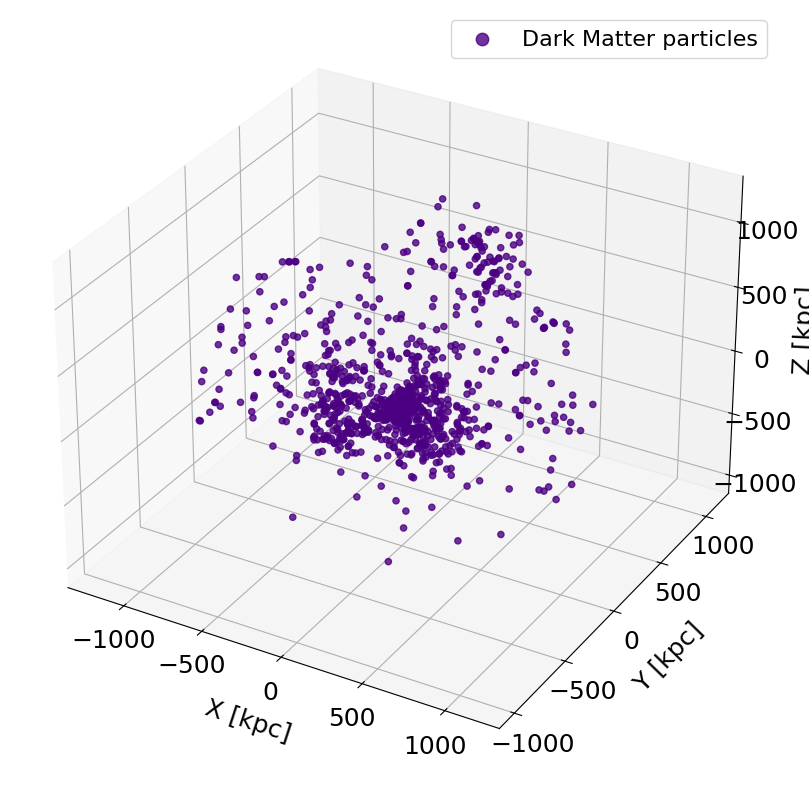

In [6]:
# Snippet of code to retrieve a visualization of the collapsing sphere
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection="3d") # creating the 3d subplot

# Retrieving the positional values in x, y, z
x = pos1[:, 0]
y = pos1[:, 1]
z = pos1[:, 2]

# Plotting
ax.scatter3D(x, y, z, alpha=0.8, color="indigo", label="Dark Matter particles")

# Setting the parameters for the axes of the plot
ax.set_xlabel("X [kpc]", fontsize=18, labelpad=12)
ax.set_ylabel("Y [kpc]", fontsize=18, labelpad=12)
ax.set_zlabel("Z [kpc]", fontsize=18, labelpad=10)

ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=18)
ax.tick_params(axis="z", labelsize=18)

fig.subplots_adjust(left=0.02, right=0.82, bottom=0.02, top=0.98)
ax.legend(markerscale=2, fontsize=16)
plt.savefig("sphere_3d_plot.pdf", dpi=300)
plt.show()

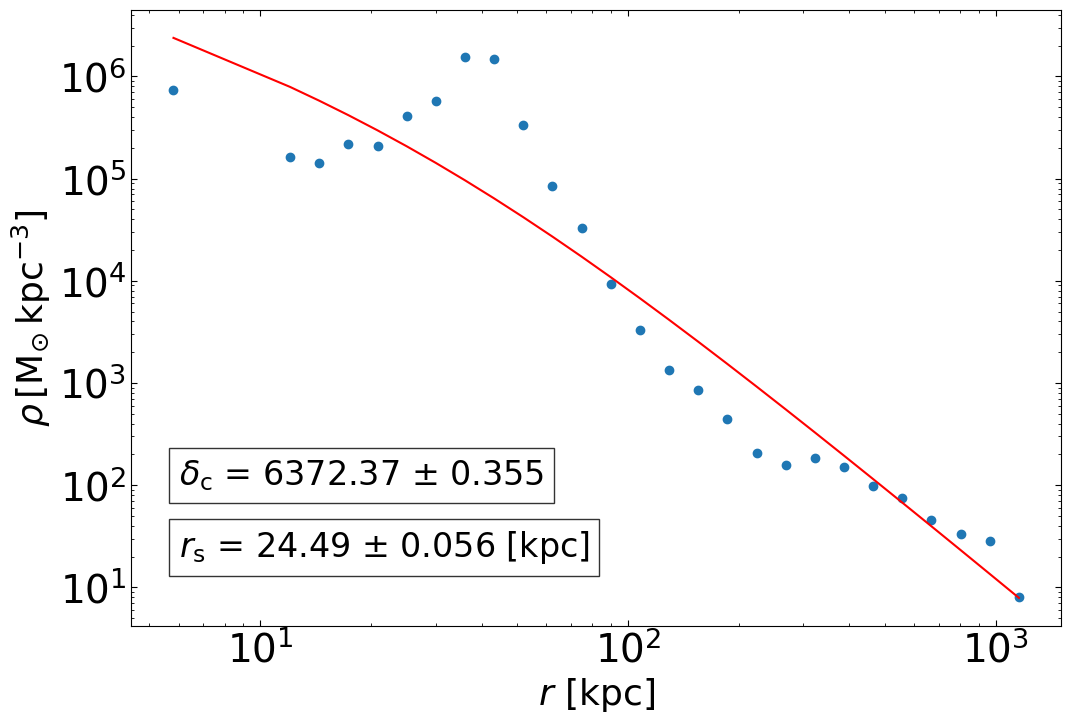

In [38]:
# Visualizing the radial profile
fig = plt.figure(figsize=(12, 8))
plt.loglog(bin_centers, vol_density, marker="o", linestyle="None")
plt.plot(bin_centers, rho_nfw_fit, color="red")
#plt.axhline(theoretical_rho, linestyle="--", color="red", label=r"$\rho$")
plt.tick_params(direction="in", which="major", length=4, labelsize=28, top=True, right=True)
plt.tick_params(direction="in", which="minor", length=2, labelsize=28, top=True, right=True)
plt.xlabel(r"$r$ [kpc]", fontsize=26)
plt.ylabel(r"$\rho \, [\rm{M_{\odot}} \, kpc^{-3}]$", fontsize=26)
plt.text(x=6, y=1e2, s=rf"$\delta_{{\rm{{c}}}}$ = {delta_c:.2f} $\pm$ {pcov[0][0]:.3f}", fontsize=24,
         bbox=dict(boxstyle="square,pad=0.3", facecolor="white", edgecolor="black", 
                   alpha=0.8))
plt.text(x=6, y=20, s=rf"$r_{{\mathrm{{s}}}}$ = {scale_radius:.2f} $\pm$ {pcov[1][1]:.3f} [$\mathrm{{kpc}}$]", fontsize=24,
         bbox=dict(boxstyle="square,pad=0.3", facecolor="white", edgecolor="black", 
                   alpha=0.8))
plt.savefig("radial_density_profile_non_expanding.pdf", dpi=300)
plt.show()

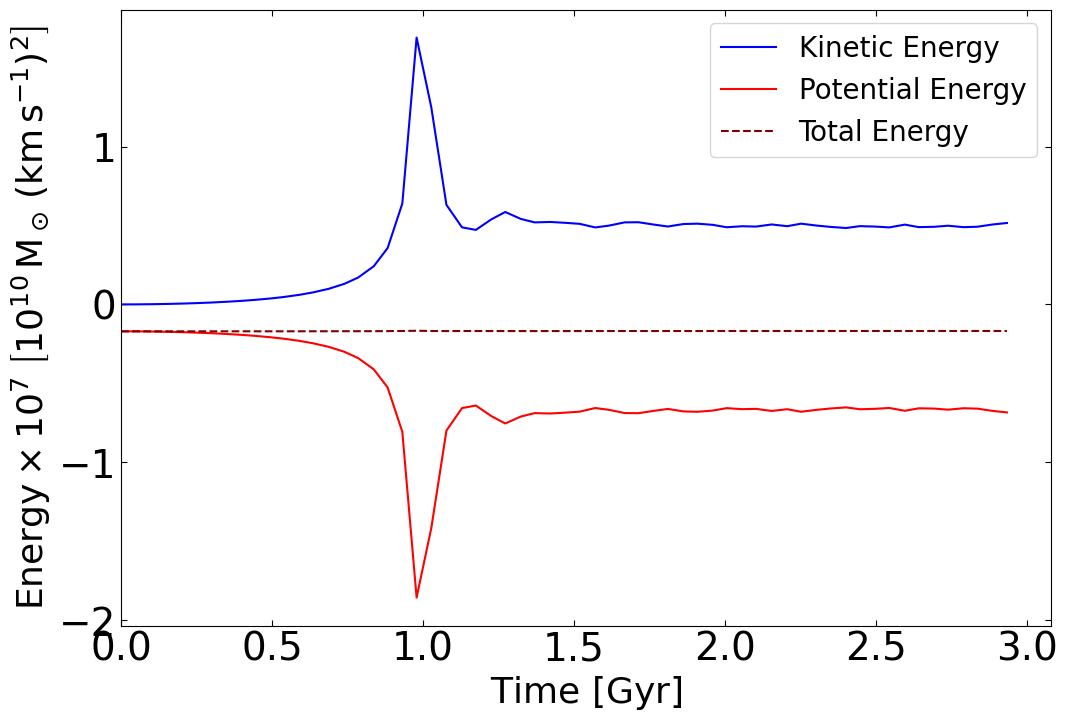

In [51]:
"Energy data and plotting"

# Extracting the energy data and plotting it for the first simulation 
energy_data = np.loadtxt("C:\\Users\\aleja\\astrofisica_teorica\\sim_num\\claudio_nbody\\output_ex4\\energy.txt")

# Extracting the data (see the Gadget4 guide for each)
time = energy_data[:,0]
total_internal = energy_data[:,1]
total_potential = energy_data[:,2]     
total_kinetic = energy_data[:,3]     
total_energy = total_kinetic + total_potential

# Conversion of time to Gyrs
kpc_km = 3.086e16
s_gyr = 3.156e16
time_conv_factor = (kpc_km)*(1/s_gyr)
time = time*time_conv_factor

# Plotting the energies
fig = plt.figure(figsize=(12, 8))
plt.plot(time, total_kinetic/1e7, label="Kinetic Energy", color="blue")
plt.plot(time, total_potential/1e7, label="Potential Energy", color="red")
plt.plot(time, total_energy/1e7, label="Total Energy", linestyle="--", color="maroon")
plt.tick_params(direction="in", which="major", length=4, labelsize=28, top=True, right=True)
plt.tick_params(direction="in", which="minor", length=2, labelsize=28, top=True, right=True)
plt.xlabel(r"Time $[\rm{Gyr}]$", fontsize=26)
plt.xlim(0)
plt.ylabel(r"$\mathrm{Energy} \times 10^{7} \;\left[10^{10} \, \mathrm{M_\odot} \, (\mathrm{km\,s^{-1}})^2\right]$", fontsize=26)
plt.legend(prop={'size': 20})
plt.savefig("energy_plot_non_expanding.pdf", dpi=300)
plt.show()

In [32]:
"Analysis and Plotting for the Expanding Universe"

"Plotting of the radial density profile"

# Importing the hdf5 snapshot file from the Gadget compilation and printing
# relevant information
h5py_file_exp = "C:\\Users\\aleja\\astrofisica_teorica\\sim_num\\claudio_nbody\\output_ex4_exp\\snapshot_006_exp.hdf5"

with h5py.File(h5py_file_exp, "r") as f:
    pos_exp = np.asarray(f["/PartType1/Coordinates"]) # kpc/h
    info_exp = np.asarray(f["/PartType1/Velocities"]) # kpc/h
"""
    print("---File Information---")
    print(list(f.keys()))
    print(list(f["PartType1"].keys()))
    #header = f["Header"].attrs
    #mass = header["MassTable"] # 1e10 Msun/h
    #stellar_mass = mass[1] # 1e10 Msun/h
    print("")
    print("---Attributes in Header---")
    for key in header.keys():
        value = header[key]
        print(f"{key}: {value}")
"""

'\n    print("---File Information---")\n    print(list(f.keys()))\n    print(list(f["PartType1"].keys()))\n    #header = f["Header"].attrs\n    #mass = header["MassTable"] # 1e10 Msun/h\n    #stellar_mass = mass[1] # 1e10 Msun/h\n    print("")\n    print("---Attributes in Header---")\n    for key in header.keys():\n        value = header[key]\n        print(f"{key}: {value}")\n'

Power law index slope: 2.60

Values of the parameters for expanding universe:
delta_c = 370217.595 + 0.259, r_s = 6.345 + 0.040 [kpc]


C:\Users\aleja\AppData\Local\Temp\ipykernel_3856\4123997914.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={'size': 20})


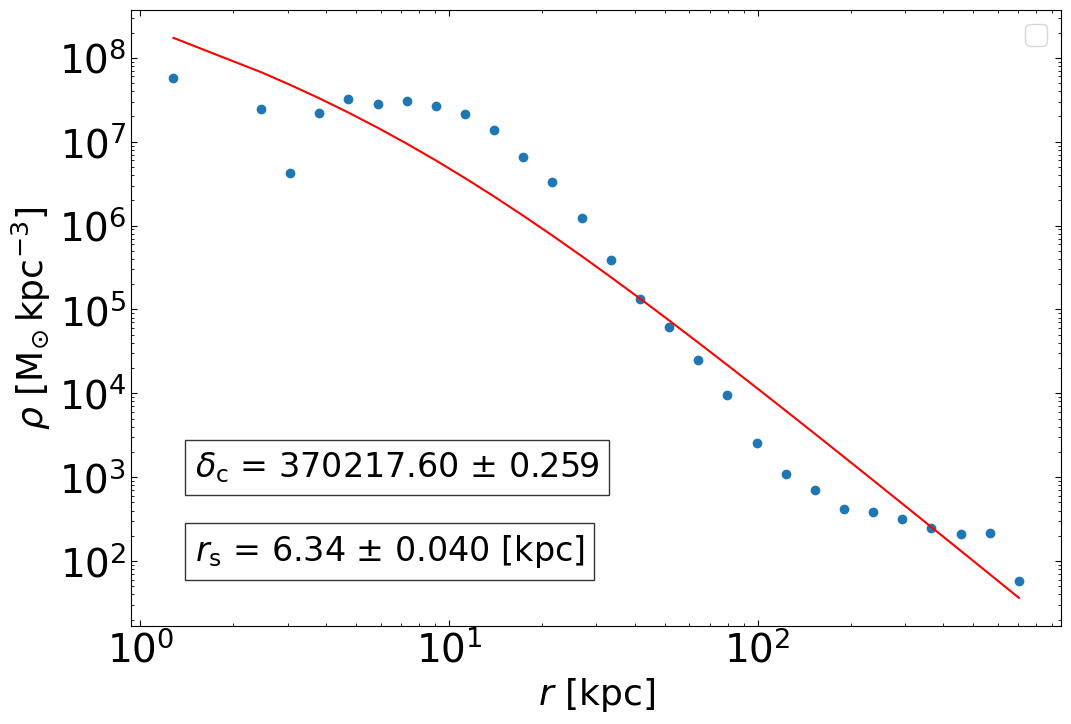

In [40]:
# Generating firstly the density profile by using np.histogram
radial_output_exp = np.linalg.norm(pos_exp, axis=1)
nbins_exp = 30 # REMEMBER TO CORRECT FOR LOGARITHMIC BINNING 
weight_array_exp = np.full_like(radial_output_exp, mass_particle)
r_min_exp, r_max_exp = radial_output_exp.min(), radial_output_exp.max()
bin_edges_exp = np.logspace(np.log10(r_min_exp), np.log10(r_max_exp), nbins_exp + 1)
hist_exp, edges_exp = np.histogram(radial_output_exp, bins=bin_edges_exp, 
                                   range=(r_min_exp, r_max_exp), 
                                   weights=weight_array_exp)

# Calculating the volume density (remember bins are spherical shells)
# Lets calculate the volume 
radius_outer_exp = edges_exp[1:]
radius_inner_exp = edges_exp[:-1]
shell_volume_exp = (4*np.pi/3)*(radius_outer_exp**3 - radius_inner_exp**3)
vol_density_exp = hist_exp/shell_volume_exp
# Geometrical mean for the radial value because of logarithmic binning
bin_centers_exp = np.sqrt(radius_inner_exp*radius_outer_exp)

# Masking the values for the fitting procedure
mask_exp = vol_density_exp > 0
bin_centers_exp = bin_centers_exp[mask_exp]
vol_density_exp = vol_density_exp[mask_exp]
vol_density_exp_physical = vol_density_exp*mass_units

# Fit the curve obtained to see the log-log slope 
log_r_exp = np.log10(bin_centers_exp)
log_rho_exp = np.log10(vol_density_exp_physical)

# Printing the value of the slope with polyfit
#mask = vol_density > 0
slope_exp, intercept_exp = np.polyfit(np.log10(bin_centers_exp), np.log10(vol_density_exp_physical), 1)
print(f"Power law index slope: {-slope_exp:.2f}")

# Obtaining the parameter values of delta_c and the scale radius for the expanding universe case
p0_exp = [3, 1]
popt_exp, pcov_exp = curve_fit(log_NFW_profile, bin_centers_exp, log_rho_exp, p0=p0_exp, maxfev=10000)
delta_c_exp = 10**(popt_exp[0])
scale_radius_exp = 10**(popt_exp[1]) # kpc
rho_nfw_fit_exp = 10**(log_NFW_profile(bin_centers_exp, popt_exp[0], popt_exp[1]))
print(f"\nValues of the parameters for expanding universe:\ndelta_c = {delta_c_exp:.3f} + {pcov_exp[0][0]:.3f}, r_s = {scale_radius_exp:.3f} + {pcov_exp[1][1]:.3f} [kpc]")

# Visualizing the result
fig = plt.figure(figsize=(12, 8))
plt.loglog(bin_centers_exp, vol_density_exp_physical, marker="o", linestyle="None")
plt.loglog(bin_centers_exp, rho_nfw_fit_exp, color="red")
plt.tick_params(direction="in", which="major", length=4, labelsize=28, top=True, right=True)
plt.tick_params(direction="in", which="minor", length=2, labelsize=28, top=True, right=True)
plt.xlabel(r"$r$ [kpc]", fontsize=26)
plt.ylabel(r"$\rho$ $[\rm{M_{\odot}} \, kpc^{-3}]$", fontsize=26)
plt.legend(prop={'size': 20})
plt.text(x=1.5, y=1e3, s=rf"$\delta_{{\rm{{c}}}}$ = {delta_c_exp:.2f} $\pm$ {pcov_exp[0][0]:.3f}", fontsize=24,
         bbox=dict(boxstyle="square,pad=0.3", facecolor="white", edgecolor="black", 
                   alpha=0.8))
plt.text(x=1.5, y=1e2, s=rf"$r_{{\mathrm{{s}}}}$ = {scale_radius_exp:.2f} $\pm$ {pcov_exp[1][1]:.3f} [$\mathrm{{kpc}}$]", fontsize=24,
         bbox=dict(boxstyle="square,pad=0.3", facecolor="white", edgecolor="black", 
                   alpha=0.8))
plt.savefig("radial_density_profile_exp.pdf", dpi=300)
plt.show()

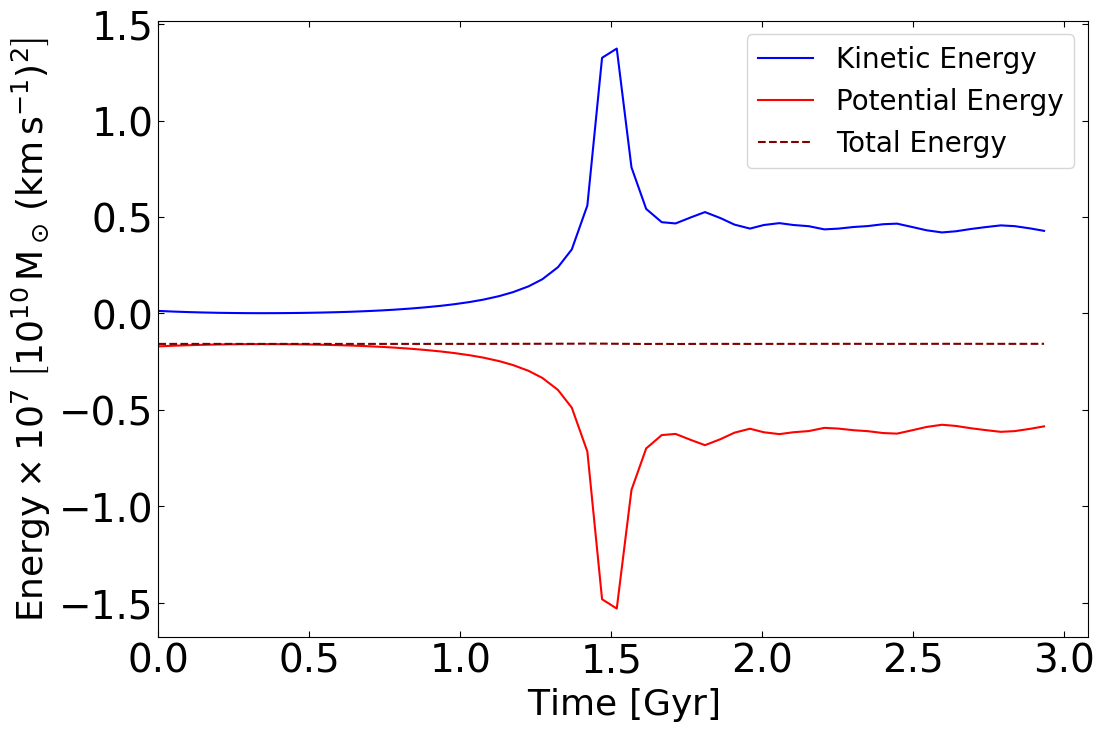

In [50]:
# Extracting the energy data in the case of an expanding universe
energy_data_exp = np.loadtxt("C:\\Users\\aleja\\astrofisica_teorica\\sim_num\\claudio_nbody\\output_ex4_exp\\energy_exp.txt") 

# Identifying each type of energy and stroing it
time_exp = energy_data_exp[:,0]
total_internal_exp = energy_data_exp[:,1]
total_potential_exp = energy_data_exp[:,2]     
total_kinetic_exp = energy_data_exp[:,3]     
total_energy_exp = total_kinetic_exp + total_potential_exp

# Converting time to Gyrs# Conversion of time to Gyrs
kpc_km = 3.086e16
s_gyr = 3.156e16
time_conv_factor = (kpc_km)*(1/s_gyr)
time_exp = time_exp*time_conv_factor

# Plotting the energies
fig = plt.figure(figsize=(12, 8))
plt.plot(time_exp, total_kinetic_exp/1e7, label="Kinetic Energy", color="blue")
plt.plot(time_exp, total_potential_exp/1e7, label="Potential Energy", color="red")
plt.plot(time_exp, total_energy_exp/1e7, label="Total Energy", linestyle="--", color="maroon")
plt.tick_params(direction="in", which="major", length=4, labelsize=28, top=True, right=True)
plt.tick_params(direction="in", which="minor", length=2, labelsize=28, top=True, right=True)
plt.xlabel(r"Time $[\rm{Gyr}]$", fontsize=26)
plt.xlim(0)
plt.ylabel(r"$\mathrm{Energy} \times 10^{7} \;\left[10^{10} \, \mathrm{M_\odot} \, (\mathrm{km\,s^{-1}})^2\right]$", fontsize=26)
plt.legend(prop={'size': 20})
plt.savefig("energy_plot_expanding.pdf", dpi=300)
plt.show()


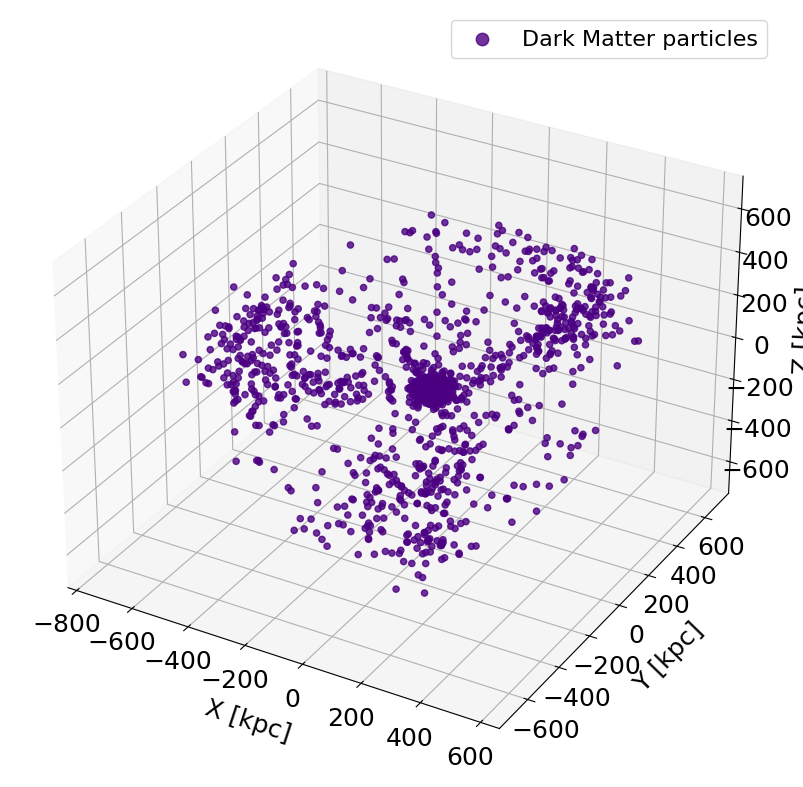

In [32]:
# Snippet of code to retrieve a visualization of the collapsing sphere
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection="3d") # creating the 3d subplot

# Retrieving the positional values in x, y, z
x = pos_exp[:, 0]
y = pos_exp[:, 1]
z = pos_exp[:, 2]

# Plotting
ax.scatter3D(x, y, z, alpha=0.8, color="indigo", label="Dark Matter particles")

# Setting the parameters for the axes of the plot
ax.set_xlabel("X [kpc]", fontsize=18, labelpad=12)
ax.set_ylabel("Y [kpc]", fontsize=18, labelpad=12)
ax.set_zlabel("Z [kpc]", fontsize=18, labelpad=10)

ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=18)
ax.tick_params(axis="z", labelsize=18)

fig.subplots_adjust(left=0.02, right=0.82, bottom=0.02, top=0.98)
ax.legend(markerscale=2, fontsize=16)
plt.savefig("sphere_3d_plot.pdf", dpi=300)
plt.show()